In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("izmir_houses.xlsx")

### EDA

In [4]:
print(df.head())

                           District     Price  \
0   İzmir / Güzelbahçe / Çamlı Mah.   7000000   
1  İzmir / Güzelbahçe / Çelebi Mah.  35000000   
2    İzmir / Torbalı / Torbalı Mah.   6500000   
3    İzmir / Selçuk / 14 Mayıs Mah.   3750000   
4       İzmir / Buca / Adatepe Mah.   1410000   

                              Rooms  Size_m2  \
0  5 +\n                          2    260.0   
1  4 +\n                          1    270.0   
2  3 +\n                          1    195.0   
3  2 +\n                          1     75.0   
4  2 +\n                          1    110.0   

                                   Age  
0   1\n                        Yaşında  
1  25\n                        Yaşında  
2   8\n                        Yaşında  
3  10\n                        Yaşında  
4                           Sıfır Bina  


In [5]:
print(df.columns)

Index(['District', 'Price', 'Rooms', 'Size_m2', 'Age'], dtype='object')


In [6]:
print(df.shape)

(979, 5)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   District  979 non-null    object 
 1   Price     979 non-null    int64  
 2   Rooms     979 non-null    object 
 3   Size_m2   979 non-null    float64
 4   Age       979 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 38.4+ KB


## Data Cleaning

In [8]:
#Functions to clean

def clean_room_count(text):
    if pd.isna(text): return None
    text = str(text)
    if "Stüdyo" in text: return 1
    if "+" in text:
        try:
            parts = text.split("+")
            return int(parts[0]) + int(parts[1])
        except: return None
    try: return int(text)
    except: return None

def clean_age(text):
    if pd.isna(text): return None
    text = str(text)
    if "Sıfır" in text: return 0 # "Sıfır" means zero
    try: return int(text.split(" ")[0]) #10 yaşında -> 10
    except: return None

def clean_district(text):
    # "İzmir / Bornova / Erzene Mah." -> "Bornova"
    try:
        return text.split("/")[1].strip()
    except:
        return text

# Applying the functions
df['Rooms'] = df['Rooms'].apply(clean_room_count)
df['Age'] = df['Age'].apply(clean_age)
df['District'] = df['District'].apply(clean_district)

# Converting to numbers
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Size_m2'] = pd.to_numeric(df['Size_m2'], errors='coerce')
# Dropped null rows
df_clean = df.dropna()
print(f"Cleaned Data: {len(df_clean)} rows.")
df_clean.head()

Cleaned Data: 979 rows.


,District,Price,Rooms,Size_m2,Age
0,Güzelbahçe,7000000,7,260.0,1
1,Güzelbahçe,35000000,5,270.0,25
2,Torbalı,6500000,4,195.0,8
3,Selçuk,3750000,3,75.0,10
4,Buca,1410000,3,110.0,0


## Visual Analysis

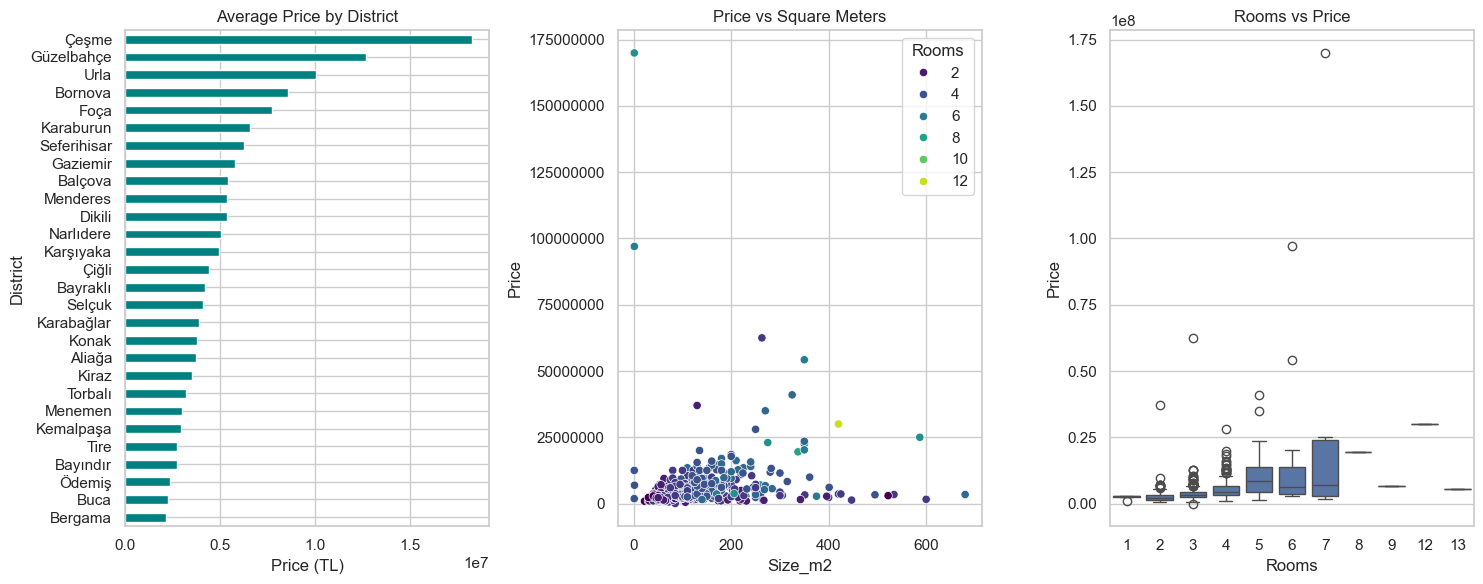

In [9]:
sns.set(style="whitegrid")
plt.figure(figsize=(15,6))

# Price Distribution by District
plt.subplot(1, 3, 1)
# Group by district, calculate average price, sort it
district_price = df_clean.groupby('District')['Price'].mean().sort_values()
district_price.plot(kind='barh', color='teal')
plt.title('Average Price by District')
plt.xlabel('Price (TL)')

# CHART 2: Price vs Size (m2)
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x='Size_m2', y='Price', hue='Rooms', palette='viridis')
plt.title('Price vs Square Meters')
plt.ticklabel_format(style='plain', axis='y') # Removed scientific notation

# Rooms vs Price
plt.subplot(1, 3, 3)
sns.boxplot(x='Rooms', y='Price', data=df_clean)
plt.title("Rooms vs Price")
plt.tight_layout()
plt.show()

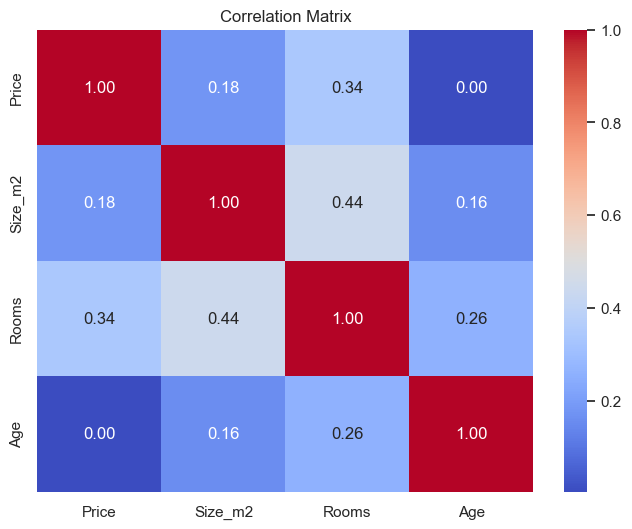

In [10]:
# Correlation Matrix
plt.figure(figsize=(8,6))
corr = df_clean[['Price', 'Size_m2', 'Rooms', 'Age']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

I realize that these correlations aren't what is expected especially size_m2 It should've been higher correlation with price. I will recheck the cleaning functions and data types.

## Outlier removal (IQR)

In [11]:
def outlier_removal_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return filtered_data
print(df_clean.describe())#old version
#removing price outliers
df_no_outliers = outlier_removal_iqr(df_clean, 'Price')
print(f"Data after price outlier removal: {len(df_no_outliers)} rows.")
df_no_outliers = outlier_removal_iqr(df_no_outliers, 'Size_m2')
print(f"Data after size outlier removal: {len(df_no_outliers)} rows.")
df_no_outliers.describe()

              Price       Rooms     Size_m2         Age
count  9.790000e+02  979.000000  979.000000  979.000000
mean   4.836278e+06    3.347293  117.877273   17.734423
std    7.538372e+06    1.048868   69.326247   14.560323
min    5.500000e+03    1.000000    1.000000    0.000000
25%    2.600000e+06    3.000000   80.000000    4.000000
50%    3.450000e+06    3.000000  105.000000   20.000000
75%    5.200000e+06    4.000000  135.000000   30.000000
max    1.700000e+08   13.000000  680.000000  150.000000
Data after price outlier removal: 906 rows.
Data after size outlier removal: 858 rows.


,Price,Rooms,Size_m2,Age
count,8.580000e+02,858.000000,858.000000,858.000000
mean,3.667948e+06,3.242424,101.213287,18.016317
std,1.762674e+06,0.936475,33.952502,14.609893
min,5.500000e+03,1.000000,22.000000,0.000000
25%,2.550000e+06,3.000000,75.000000,4.000000
50%,3.250000e+06,3.000000,100.000000,20.000000
75%,4.500000e+06,4.000000,122.500000,30.000000
max,9.000000e+06,13.000000,206.000000,150.000000


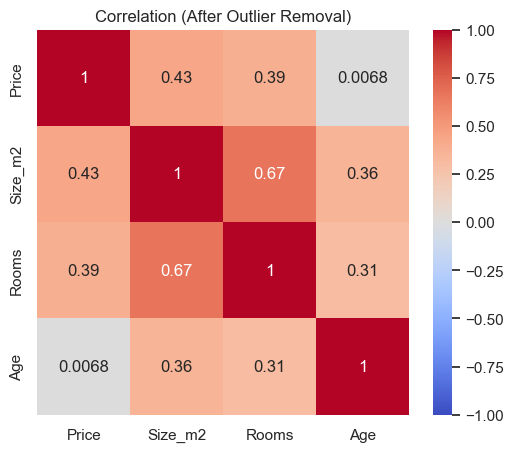

In [12]:
plt.figure(figsize=(6, 5))
correlation = df_no_outliers[['Price', 'Size_m2', 'Rooms', 'Age']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation (After Outlier Removal)')
plt.show()

In [13]:
# 1. Check for "Impossible" Sizes
print("Unrealistic big houses (< 30m2)\n")
print(df_no_outliers[df_no_outliers['Size_m2'] < 30][['District', 'Price', 'Size_m2', 'Rooms']])

print("\nUnrealistic big houses (> 400m2)")
print(df_no_outliers[df_no_outliers['Size_m2'] > 400][['District', 'Price', 'Size_m2', 'Rooms']])

# 2. Check for "Impossible" Prices vs Size
# (e.g., Giant house for cheap, or Tiny house for millions)
df_no_outliers['Price_per_m2'] = df_no_outliers['Price'] / df_no_outliers['Size_m2']
print("\nCheapest Prices per m2 (Likely Errors or Land)")
print(df_no_outliers.sort_values('Price_per_m2').head(5)[['District', 'Price', 'Size_m2', 'Price_per_m2']])

print("\nMost Expensive Prices per m2")
print(df_no_outliers.sort_values('Price_per_m2', ascending=False).head(10)[['District', 'Price', 'Size_m2', 'Price_per_m2']])

Unrealistic big houses (< 30m2)

    District   Price  Size_m2  Rooms
278    Konak  880000     22.0      1

Unrealistic big houses (> 400m2)
Empty DataFrame
Columns: [District, Price, Size_m2, Rooms]
Index: []

Cheapest Prices per m2 (Likely Errors or Land)
     District    Price  Size_m2  Price_per_m2
592  Menderes     5500     85.0     64.705882
753  Bayındır   475000    106.0   4481.132075
665    Ödemiş  1000000    179.0   5586.592179
654      Tire   990000    174.0   5689.655172
758    Ödemiş  1350000    193.0   6994.818653

Most Expensive Prices per m2
      District    Price  Size_m2   Price_per_m2
502  Karaburun  7075000     52.0  136057.692308
701      Çeşme  6500000     50.0  130000.000000
814    Bornova  7100000     56.0  126785.714286
730      Çeşme  6300000     50.0  126000.000000
47   Karşıyaka  6950000     58.0  119827.586207
570       Foça  8890000     75.0  118533.333333
16       Çeşme  8750000     75.0  116666.666667
485    Bornova  5150000     45.0  114444.444444
98  

77 Seferihisar with 6000 try price is unrealistic It is probably monthly rent price so we need to remove outliers by hand as well.

In [14]:
print(f"Before removal row count: {len(df_no_outliers)}")
print(df_no_outliers.describe())
print()
df_no_outliers = df_no_outliers[df_no_outliers['Price'] > 500000] # higher than 500k
df_no_outliers = df_no_outliers[df_no_outliers['Price'] < 100000000] #smaller tahan 100m

df_no_outliers = df_no_outliers[df_no_outliers['Size_m2'] < 400]
df_no_outliers = df_no_outliers[df_no_outliers['Size_m2'] > 30]
print(f"After removal row count: {len(df_no_outliers)}")
df_no_outliers.describe()


Before removal row count: 858
              Price       Rooms     Size_m2         Age   Price_per_m2
count  8.580000e+02  858.000000  858.000000  858.000000     858.000000
mean   3.667948e+06    3.242424  101.213287   18.016317   37971.510669
std    1.762674e+06    0.936475   33.952502   14.609893   17975.742935
min    5.500000e+03    1.000000   22.000000    0.000000      64.705882
25%    2.550000e+06    3.000000   75.000000    4.000000   25833.333333
50%    3.250000e+06    3.000000  100.000000   20.000000   35000.000000
75%    4.500000e+06    4.000000  122.500000   30.000000   46666.666667
max    9.000000e+06   13.000000  206.000000  150.000000  136057.692308

After removal row count: 853


,Price,Rooms,Size_m2,Age,Price_per_m2
count,8.530000e+02,853.000000,853.000000,853.000000,853.000000
mean,3.684032e+06,3.250879,101.486518,18.000000,38014.470867
std,1.754240e+06,0.930894,33.761785,14.624566,17894.544075
min,6.250000e+05,1.000000,32.000000,0.000000,5586.592179
25%,2.550000e+06,3.000000,76.000000,4.000000,25833.333333
50%,3.250000e+06,3.000000,100.000000,20.000000,35000.000000
75%,4.500000e+06,4.000000,125.000000,30.000000,46666.666667
max,9.000000e+06,13.000000,206.000000,150.000000,136057.692308


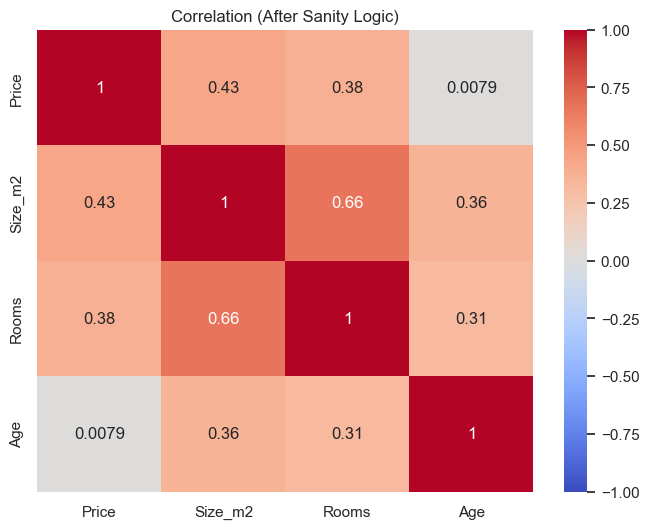

In [15]:
plt.figure(figsize=(8, 6))
correlation = df_no_outliers[['Price', 'Size_m2', 'Rooms', 'Age']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation (After Sanity Logic)')
plt.show()

We did manual outlier removal as well. Correlation looks almost same after that. I guess those outliers were not affecting much. The real reason might be data quality itself or Maybe the location affect is much more than expected.

### Correlation per District Heatmap

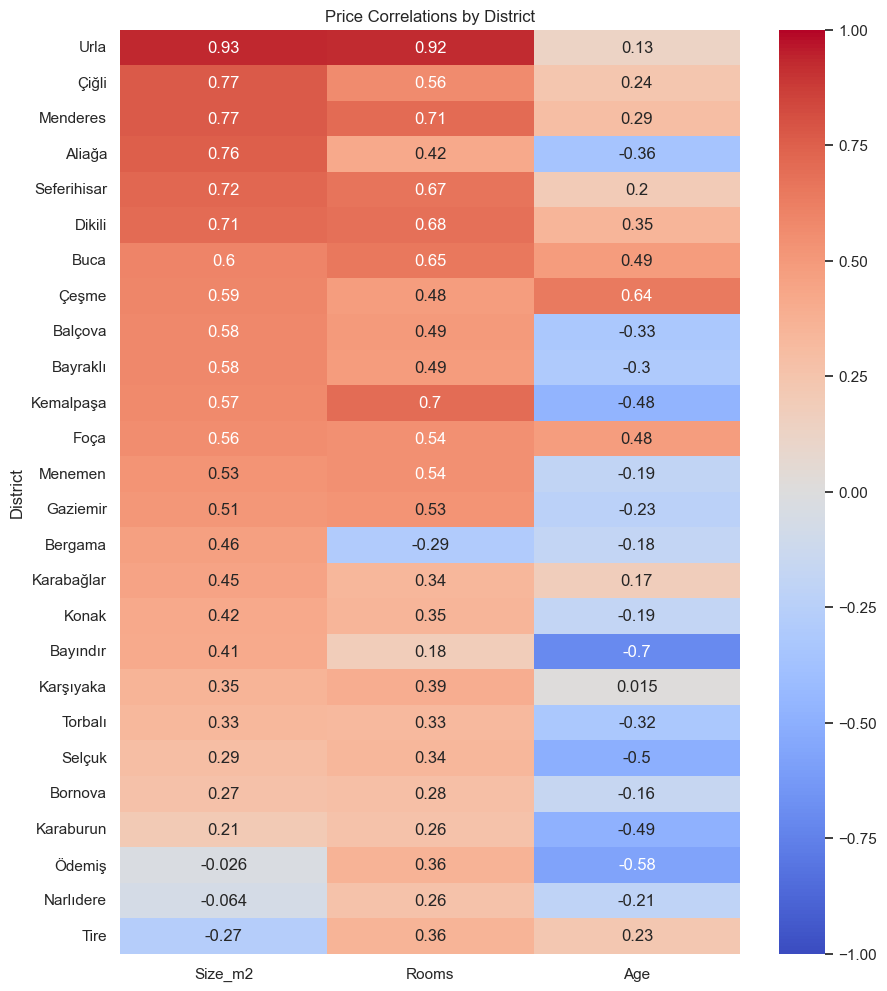

In [16]:

# We group by District, calculate correlations, and then grab just the 'Price' column
district_corrs = df_no_outliers.groupby('District')[['Price', 'Size_m2', 'Rooms', 'Age']].corr().unstack()['Price']

# Drop the 'Price' column (because correlation of Price vs Price is always 1.0)
district_corrs = district_corrs.drop(columns=['Price'])

# Remove districts with NaN values
district_corrs = district_corrs.dropna()

# Sorting by 'Size_m2' 
district_corrs = district_corrs.sort_values(by='Size_m2', ascending=False)

# 3. PLOT THE MASTER HEATMAP
plt.figure(figsize=(10, 12)) # Tall chart to fit all districts
sns.heatmap(district_corrs, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Price Correlations by District')
plt.show()

Now we see that Size_m2 is the most important factor for price in almost all districts. Some districts probably have pools or gardens breaks the logic.

In [19]:
import pickle
from sklearn.ensemble import RandomForestRegressor
 
# 1. We calculate the average price of every district.
# The App needs this to know that "Konak" is Tier 3.
district_avgs = df_no_outliers.groupby('District')['Price'].mean()
# I will divide the average prices into 3 tiers:
Q1 = district_avgs.quantile(0.33)
Q2 = district_avgs.quantile(0.66)

# 2. We divide districts into 3 tiers based on average price
def get_tier(district):
    avg = district_avgs[district] 
    if avg >= Q2: return 3
    elif avg >= Q1: return 2
    else: return 1

df_no_outliers['Tier'] = df_no_outliers['District'].apply(get_tier)

# 3. Training final model
X = df_no_outliers[['Rooms', 'Size_m2', 'Tier']]
y = df_no_outliers['Price']

print("Training final model...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 4. Saving two keys
pickle.dump(model, open("model.pkl", "wb")) # Brain
pickle.dump(district_avgs, open("district_avgs.pkl", "wb")) # Memory

print("Training complete.")
print("Check your folder for 'model.pkl' and 'district_avgs.pkl'.")

Training final model...
Training complete.
Check your folder for 'model.pkl' and 'district_avgs.pkl'.
